# Lab Vision Systems: Session 7

# Today:

### 1: Transformers
### 2: Image Classification with Vision Transformers

---

---

---

# 0. Announcements

# 2. Transformers

# 3. Image Classification with Vision Transformers

In [5]:
import os
import random
import math
import shutil
from tqdm import tqdm
import numpy as np
import cv2
import matplotlib.pyplot as plt
from torch.utils.tensorboard import SummaryWriter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import datasets, models, transforms

In [6]:
a = torch.ones(1).cuda()

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [8]:
torch.cuda.is_available()

True

## Dataset

In [9]:
# Downloading and Loading Dataset
train_tf = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(degrees=25),
        transforms.ColorJitter(brightness=.5, hue=.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor()
    ])

val_tf = transforms.Compose([
        transforms.ToTensor()
    ])

# train + valid splits
train_db = datasets.CIFAR10(root='./data', train=True, transform=train_tf, download=True)

# eval set
test_db = datasets.CIFAR10(root='./data', train=False, transform=val_tf)

Files already downloaded and verified


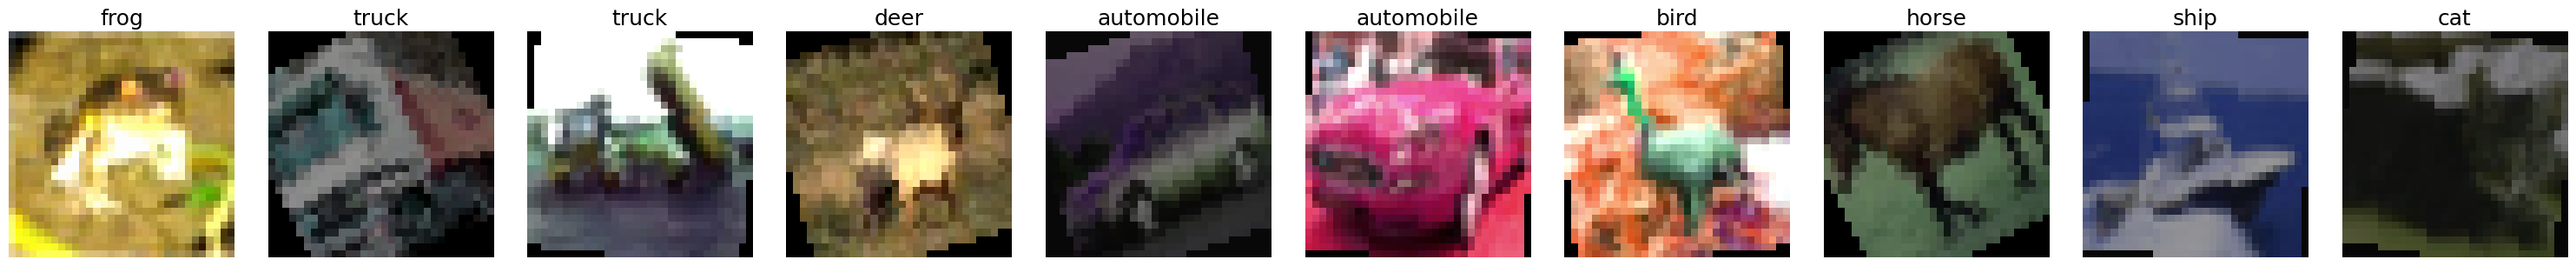

In [10]:
fig, ax = plt.subplots(1, 10, figsize=(30,3))

for i in range(10):
    img, lbl = train_db[i]
    ax[i].imshow(img.permute(1, 2, 0))
    ax[i].set_title(train_db.classes[lbl], fontsize=18)
    ax[i].axis("off")

plt.tight_layout()
plt.show()

In [11]:
train_loader = torch.utils.data.DataLoader(dataset=train_db, batch_size=256, shuffle=True) 
test_loader = torch.utils.data.DataLoader(dataset=test_db, batch_size=256, shuffle=False) 

## Utils

In [12]:
# utils

def smooth(f, K=5):
    """ Smoothing a function using a low-pass filter (mean) of size K """
    kernel = np.ones(K) / K
    f = np.concatenate([f[:int(K//2)], f, f[int(-K//2):]])  # to account for boundaries
    smooth_f = np.convolve(f, kernel, mode="same")
    smooth_f = smooth_f[K//2: -K//2]  # removing boundary-fixes
    return smooth_f


def save_model(model, optimizer, epoch, stats):
    """ Saving model checkpoint """
    
    if(not os.path.exists("checkpoints")):
        os.makedirs("checkpoints")
    savepath = f"checkpoints/checkpoint_epoch_{epoch}.pth"

    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'stats': stats
    }, savepath)
    return


def load_model(model, optimizer, savepath):
    """ Loading pretrained checkpoint """
    
    checkpoint = torch.load(savepath, map_location="cpu")
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    epoch = checkpoint["epoch"]
    stats = checkpoint["stats"]
    
    return model, optimizer, epoch, stats


def count_model_params(model):
    """ Counting the number of learnable parameters in a nn.Module """
    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return num_params


def visualize_progress(loss_iters, train_loss, val_loss, valid_acc, start=0):
    """ Visualizing loss and accuracy """
    plt.style.use('seaborn')
    fig, ax = plt.subplots(1,3)
    fig.set_size_inches(24,5)
    
    smooth_loss = smooth(loss_iters, 31)
    ax[0].plot(loss_iters, c="blue", label="Loss", linewidth=3, alpha=0.5)
    ax[0].plot(smooth_loss, c="red", label="Smoothed Loss", linewidth=3, alpha=1)
    ax[0].legend(loc="best")
    ax[0].set_xlabel("Iteration")
    ax[0].set_ylabel("CE Loss")
    ax[0].set_title("Training Progress")
    
    epochs = np.arange(len(train_loss)) + 1
    ax[1].plot(epochs, train_loss, c="red", label="Train Loss", linewidth=3)
    ax[1].plot(epochs, val_loss, c="blue", label="Valid Loss", linewidth=3)
    ax[1].legend(loc="best")
    ax[1].set_xlabel("Epochs")
    ax[1].set_ylabel("CE Loss")
    ax[1].set_title("Loss Curves")
    
    epochs = np.arange(len(val_loss)) + 1
    ax[2].plot(epochs, valid_acc, c="red", label="Valid accuracy", linewidth=3)
    ax[2].legend(loc="best")
    ax[2].set_xlabel("Epochs")
    ax[2].set_ylabel("Accuracy (%)")
    ax[2].set_title(f"Valdiation Accuracy (max={round(np.max(valid_acc),2)}% @ epoch {np.argmax(valid_acc)+1})")
    
    plt.show()
    return


## Attention Basics

### Attention

In [13]:
class MultiHeadSelfAttention(nn.Module):
    """ 
    Self-Attention module

    Args:
    -----
    token_dim: int
        Dimensionality of the tokens in the transformer
    inner_dim: int
        Dimensionality used for attention
    """

    def __init__(self, token_dim, attn_dim, num_heads):
        """ """
        super().__init__()
        self.token_dim = token_dim
        self.attn_dim = attn_dim
        self.num_heads = num_heads
        assert num_heads >= 1
        assert attn_dim % num_heads == 0, f"{attn_dim = } must be divisible by {num_heads = }..."
        self.head_dim = attn_dim // num_heads

        # query, key and value projections
        self.q = nn.Linear(token_dim, attn_dim, bias=False)
        self.k = nn.Linear(token_dim, attn_dim, bias=False)
        self.v = nn.Linear(token_dim, attn_dim, bias=False)

        # output projection
        self.out_proj = nn.Linear(attn_dim, token_dim, bias=False)
        return
    
    def attention(self, query, key, value):
        """
        Computing self-attention

        All (q,k,v) ~ (B, N, D)
        """
        scale = (query.shape[-1]) ** (-0.5)

        # similarity between each query and the keys
        similarity = torch.bmm(query, key.permute(0, 2, 1)) * scale  # ~(B, N, N)
        attention = similarity.softmax(dim=-1)
        self.attention_map = attention

        # attention * values
        output = torch.bmm(attention, value)
        return output

    def split_into_heads(self, x):
        """
        Splitting a vector into multiple heads
        """
        batch_size, num_tokens, _ = x.shape
        x = x.view(batch_size, num_tokens, self.num_heads, self.head_dim)  # split dimension into heads
        y = x.permute(0, 2, 1, 3).reshape(batch_size * self.num_heads, num_tokens, self.head_dim)  # why?
        return y

    def merge_heads(self, x):
        """
        Rearranging heads and recovering original shape
        """
        _, num_tokens, dim_head = x.shape
        x = x.reshape(-1, self.num_heads, num_tokens, dim_head).transpose(1, 2)
        y = x.reshape(-1, num_tokens, self.num_heads * dim_head)
        return y


    def forward(self, x):
        """ 
        Forward pass through Self-Attention module
        """
        # linear projections and splitting into heads:
        # (B, N, D) --> (B, N, Nh, Dh) --> (B * Nh, N, Dh)
        q, k, v = self.q(x), self.k(x), self.v(x)
        q = self.split_into_heads(q)
        k = self.split_into_heads(k)
        v = self.split_into_heads(v)

        # applying attention equation
        vect = self.attention(query=q, key=k, value=v)

        # rearranging heads and recovering shape:
        # (B * Nh, N, Dh) --> (B N, Nh, Dh) --> (B, N, D)
        y = self.merge_heads(vect)
        y = self.out_proj(y)
        return y

### MLP

In [14]:
class MLP(nn.Module):
    """
    2-Layer Multi-Layer Perceptron used in transformer blocks
    
    Args:
    -----
    in_dim: int
        Dimensionality of the input embeddings to the MLP
    hidden_dim: int
        Hidden dimensionality of the MLP
    """
    
    def __init__(self, in_dim, hidden_dim):
        """ MLP Initializer """
        super().__init__()
        self.mlp = nn.Sequential(
                nn.Linear(in_dim, hidden_dim),
                nn.GELU(),
                nn.Linear(hidden_dim, in_dim),
            )
        
    def forward(self, x):
        """ Forward """
        y = self.mlp(x)
        return y

### Transformer

In [15]:
class TransformerBlock(nn.Module):
    """
    Transformer block using self-attention

    Args:
    -----
    token_dim: int
        Dimensionality of the input tokens
    attn_dim: int
        Inner dimensionality of the attention module. Must be divisible be num_heads
    num_heads: int
        Number of heads in the self-attention mechanism
    mlp_size: int
        Hidden dimension of the MLP module
    """

    def __init__(self, token_dim, attn_dim, num_heads, mlp_size):
        """ Module initializer """
        super().__init__()
        self.token_dim = token_dim
        self.mlp_size = mlp_size
        self.attn_dim = attn_dim
        self.num_heads = num_heads

        # MHA
        self.ln_att = nn.LayerNorm(token_dim, eps=1e-6)
        self.attn = MultiHeadSelfAttention(
                token_dim=token_dim,
                attn_dim=attn_dim,
                num_heads=num_heads
            )
        
        # MLP
        self.ln_mlp = nn.LayerNorm(token_dim, eps=1e-6)
        self.mlp = MLP(
                in_dim=token_dim,
                hidden_dim=mlp_size,
            )
        return


    def forward(self, inputs):
        """
        Forward pass through transformer encoder block.
        We assume the more modern PreNorm design
        """
        assert inputs.ndim == 3

        # Self-attention.
        x = self.ln_att(inputs)
        x = self.attn(x)
        y = x + inputs

        # MLP
        z = self.ln_mlp(y)
        z = self.mlp(z)
        z = z + y

        return z


    def get_attention_masks(self):
        """ Fetching last computer attention masks """
        attn_masks = self.attn.attention_map
        N = attn_masks.shape[-1]
        attn_masks = attn_masks.reshape(-1, self.num_heads, N, N)
        return attn_masks

### Testing Transformer

In [16]:
tf_block = TransformerBlock(
        token_dim=128,
        attn_dim=128,
        num_heads=4,
        mlp_size=512
    ).to(device)

In [17]:
print(f"Transformer-Block has {count_model_params(tf_block)} parameters")
tf_block

Transformer-Block has 197760 parameters


TransformerBlock(
  (ln_att): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
  (attn): MultiHeadSelfAttention(
    (q): Linear(in_features=128, out_features=128, bias=False)
    (k): Linear(in_features=128, out_features=128, bias=False)
    (v): Linear(in_features=128, out_features=128, bias=False)
    (out_proj): Linear(in_features=128, out_features=128, bias=False)
  )
  (ln_mlp): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
  (mlp): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=128, out_features=512, bias=True)
      (1): GELU()
      (2): Linear(in_features=512, out_features=128, bias=True)
    )
  )
)

In [18]:
tokens = torch.rand((4, 16, 128), device=device)
out = tf_block(tokens)
attn_map = tf_block.get_attention_masks()

print(f"Input Shape: {tokens.shape}")
print(f"Output Shape: {out.shape}")
print(f"Attn. Map Shape: {attn_map.shape}")

Input Shape: torch.Size([4, 16, 128])
Output Shape: torch.Size([4, 16, 128])
Attn. Map Shape: torch.Size([4, 4, 16, 16])


## Additional Modules

### Patchification

In [19]:
class Patchifier:
    """ 
    Module that splits an image into patches.
    We assumen square images and patches
    """

    def __init__(self, patch_size):
        """ """
        self.patch_size = patch_size

    def __call__(self, img):
        """ """
        B, C, H, W = img.shape
        assert H % self.patch_size == 0
        assert W % self.patch_size == 0
        num_patch_H = H // self.patch_size
        num_patch_W = W // self.patch_size

        # splitting and reshaping
        patch_data = img.reshape(B, C, num_patch_H, self.patch_size, num_patch_W, self.patch_size)
        patch_data = patch_data.permute(0, 2, 4, 1, 3, 5)  # ~(B, n_p_h, n_p_w, C, p_s, p_s)
        patch_data = patch_data.reshape(B, num_patch_H * num_patch_W, C * self.patch_size * self.patch_size)
        return patch_data

In [26]:
patchifier = Patchifier(patch_size=8)

In [27]:
img, _ = next(iter(test_loader))
patch_data = patchifier(img)

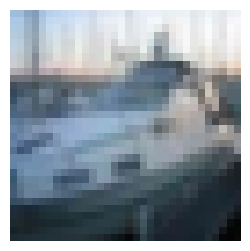

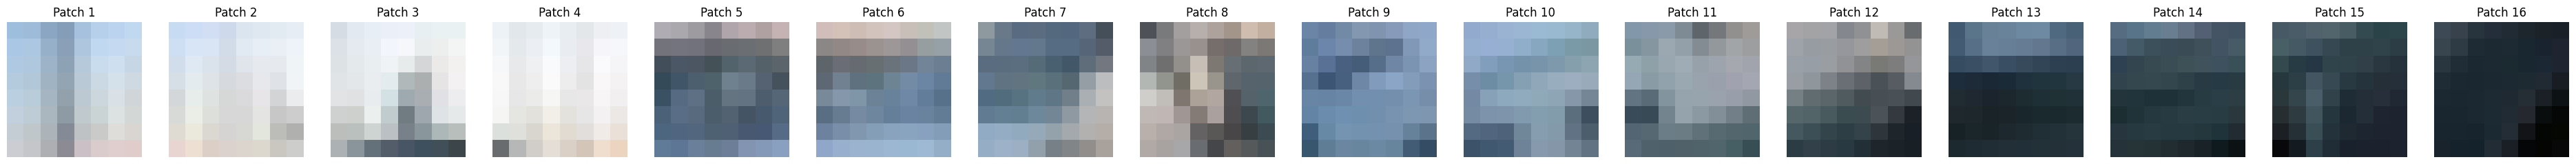

In [28]:
BATCH_IDX = 2

plt.figure(figsize=(3, 3))
plt.imshow(img[BATCH_IDX].permute(1, 2, 0))
plt.axis("off")

num_patches = patch_data.shape[1]
patch_size = patchifier.patch_size
fig, ax = plt.subplots(1, num_patches)
fig.set_size_inches(3 * num_patches, 3)
for i in range(num_patches):
    cur_patch = patch_data[BATCH_IDX, i].reshape(3, patch_size, patch_size)
    ax[i].imshow(cur_patch.permute(1, 2, 0))
    ax[i].set_title(f"Patch {i+1}")
    ax[i].axis("off")

plt.show()

### Positional Encoding

In [29]:
class PositionalEncoding(nn.Module):
    """
    Sinusoidal Positional encoding 

    Args:
    -----
    d_model: int
        Dimensionality of the slots/tokens
    max_len: int
        Length of the sequence.
    """

    def __init__(self, d_model, max_len=50):
        """
        Initializing the positional encoding
        """
        super().__init__()
        self.d_model = d_model
        self.max_len = max_len

        # initializing embedding
        self.pe = self._get_pe()
        return

    def _get_pe(self):
        """
        Initializing the temporal positional encoding given the encoding mode
        """
        max_len = self.max_len
        d_model = self.d_model
        
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.view(1, max_len, d_model)
        return pe

    def forward(self, x):
        """
        Adding the positional encoding to the input tokens of the transformer
        """
        if x.device != self.pe.device:
            self.pe = self.pe.to(x.device)
        batch_size, num_tokens = x.shape[0], x.shape[1]
        cur_pe = self.pe.repeat(batch_size, 1, 1)[:, :num_tokens]

        y = x + cur_pe
        return y

In [30]:
pe = PositionalEncoding(d_model=128, max_len=64)

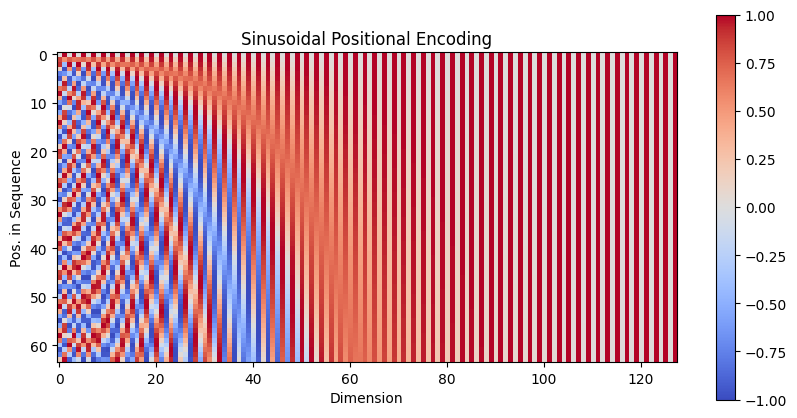

In [31]:
plt.figure(figsize=(10, 5))
plt.imshow(pe.pe[0], vmin=-1, vmax=1, cmap="coolwarm")
plt.colorbar()
plt.title("Sinusoidal Positional Encoding")
plt.xlabel("Dimension")
plt.ylabel("Pos. in Sequence")
plt.show()

## Vision Transformer 

In [32]:
class ViT(nn.Module):
    """ 
    Vision Transformer for image classification
    """

    def __init__(self, patch_size, token_dim, attn_dim, num_heads, mlp_size, num_tf_layers, num_classes):
        """ Model initializer """
        super().__init__()

        # breaking image into patches, and projection to transformer token dimension
        self.pathchifier = Patchifier(patch_size)
        self.patch_projection = nn.Sequential(
                nn.LayerNorm(patch_size * patch_size * 3),
                nn.Linear(patch_size * patch_size * 3, token_dim)
            )

        # adding CLS token and positional embedding
        self.cls_token = nn.Parameter(torch.randn(1, token_dim) / (token_dim ** 0.5), requires_grad=True)
        self.pos_emb = PositionalEncoding(token_dim)

        # cascade of transformer blocks
        transformer_blocks = [
            TransformerBlock(
                    token_dim=token_dim,
                    attn_dim=attn_dim,
                    num_heads=num_heads,
                    mlp_size=mlp_size
                )
            for _ in range(num_tf_layers)
        ]
        self.transformer_blocks = nn.Sequential(*transformer_blocks)

        # classifier
        self.classifier = nn.Linear(token_dim, num_classes)
        return

    
    def forward(self, x):
        """ 
        Forward pass
        """
        B = x.shape[0]  # (B, 3, 32, 32)
        
        # breaking image into patches, and projection to transformer token dimension
        patches = self.pathchifier(x)  # (B, 16, 8 * 8 * 3)
        patch_tokens = self.patch_projection(patches)  # (B, 16, D)

        # concatenating CLS token and adding positional embeddings
        cur_cls_token = self.cls_token.unsqueeze(0).repeat(B, 1, 1)
        tokens = torch.cat([cur_cls_token, patch_tokens], dim=1)  # ~(B, 1 + 16, D)
        tokens_with_pe = self.pos_emb(tokens)

        # processing with transformer
        out_tokens = self.transformer_blocks(tokens_with_pe)
        out_cls_token = out_tokens[:, 0]  # fetching only CLS token

        # classification
        logits = self.classifier(out_cls_token)
        return logits


    def get_attn_mask(self):
        """
        Fetching the last attention maps from all TF Blocks
        """
        attn_masks = [tf.get_attention_masks() for tf in self.transformer_blocks]
        return attn_masks


In [33]:
vit = ViT(
        patch_size=8,
        token_dim=128,
        attn_dim=128,
        num_heads=4,
        mlp_size=512,
        num_tf_layers=4,
        num_classes=10
    ).to(device)

In [34]:
print(f"ViT has {count_model_params(vit)} parameters")
vit

ViT has 817546 parameters


ViT(
  (patch_projection): Sequential(
    (0): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=192, out_features=128, bias=True)
  )
  (pos_emb): PositionalEncoding()
  (transformer_blocks): Sequential(
    (0): TransformerBlock(
      (ln_att): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
      (attn): MultiHeadSelfAttention(
        (q): Linear(in_features=128, out_features=128, bias=False)
        (k): Linear(in_features=128, out_features=128, bias=False)
        (v): Linear(in_features=128, out_features=128, bias=False)
        (out_proj): Linear(in_features=128, out_features=128, bias=False)
      )
      (ln_mlp): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
      (mlp): MLP(
        (mlp): Sequential(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): GELU()
          (2): Linear(in_features=512, out_features=128, bias=True)
        )
      )
    )
    (1): TransformerBlock(
      (ln_att): Laye

In [35]:
x = torch.rand((2, 3, 32, 32), device=device)
with torch.no_grad():
    y = vit(x)
attn_maps = vit.get_attn_mask()

In [36]:
print(f"Input Shape: {x.shape}")
print(f"Output Shape: {y.shape}")
print(f"Found {len(attn_maps)} Attn Masps of shape {attn_maps[0].shape}")

Input Shape: torch.Size([2, 3, 32, 32])
Output Shape: torch.Size([2, 10])
Found 4 Attn Masps of shape torch.Size([2, 4, 17, 17])


## Training Code

In [37]:
def train_epoch(model, train_loader, optimizer, criterion, epoch, device):
    """ Training a model for one epoch """
    
    loss_list = []
    for i, (images, labels) in enumerate(tqdm(train_loader)):
        images = images.to(device)
        labels = labels.to(device)
        
        # Clear gradients w.r.t. parameters
        optimizer.zero_grad()
         
        # Forward pass to get output/logits
        outputs = model(images)
         
        # Calculate Loss: softmax --> cross entropy loss
        loss = criterion(outputs, labels)
        loss_list.append(loss.item())
         
        # Getting gradients w.r.t. parameters
        loss.backward()
         
        # Updating parameters
        optimizer.step()
        
    mean_loss = np.mean(loss_list)
    return mean_loss, loss_list


@torch.no_grad()
def eval_model(model, eval_loader, criterion, device):
    """ Evaluating the model for either validation or test """
    correct = 0
    total = 0
    loss_list = []
    
    for images, labels in eval_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass only to get logits/output
        outputs = model(images)
                 
        loss = criterion(outputs, labels)
        loss_list.append(loss.item())
            
        # Get predictions from the maximum value
        preds = torch.argmax(outputs, dim=1)
        correct += len( torch.where(preds==labels)[0] )
        total += len(labels)
                 
    # Total correct predictions and loss
    accuracy = correct / total * 100
    loss = np.mean(loss_list)
    
    return accuracy, loss


def train_model(model, optimizer, scheduler, criterion, train_loader, valid_loader, num_epochs, tboard=None, start_epoch=0):
    """ Training a model for a given number of epochs"""
    
    train_loss = []
    val_loss =  []
    loss_iters = []
    valid_acc = []

    for epoch in range(num_epochs):
        print(f"Started Epoch {epoch+1}/{num_epochs}...")
        
        # validation epoch
        print("  --> Running valdiation epoch")
        model.eval()  # important for dropout and batch norms
        accuracy, loss = eval_model(
                    model=model, eval_loader=valid_loader,
                    criterion=criterion, device=device
            )
        valid_acc.append(accuracy)
        val_loss.append(loss)
        tboard.add_scalar(f'Accuracy/Valid', accuracy, global_step=epoch+start_epoch)
        tboard.add_scalar(f'Loss/Valid', loss, global_step=epoch+start_epoch)
        
        # training epoch
        print("  --> Running train epoch")
        model.train()  # important for dropout and batch norms
        mean_loss, cur_loss_iters = train_epoch(
                model=model, train_loader=train_loader, optimizer=optimizer,
                criterion=criterion, epoch=epoch, device=device
            )
        scheduler.step()
        train_loss.append(mean_loss)
        tboard.add_scalar(f'Loss/Train', mean_loss, global_step=epoch+start_epoch)

        loss_iters = loss_iters + cur_loss_iters
        
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"    Train loss: {round(mean_loss, 5)}")
        print(f"    Valid loss: {round(loss, 5)}")
        print(f"    Valid Accuracy: {accuracy}%")
        print("\n")
    
    print(f"Training completed")
    return train_loss, val_loss, loss_iters, valid_acc

## Model Training

In [38]:
vit = ViT(
        patch_size=8,
        token_dim=128,
        attn_dim=128,
        num_heads=4,
        mlp_size=512,
        num_tf_layers=4,
        num_classes=10
    ).to(device)

# classification loss function
criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer = torch.optim.Adam(vit.parameters(), lr=3e-4)

# Decay LR by a factor of 3 every 5 epochs
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=1/3)

In [40]:
TBOARD_LOGS = os.path.join(os.getcwd(), "tboard_logs", "ViT_30")
if not os.path.exists(TBOARD_LOGS):
    os.makedirs(TBOARD_LOGS)

shutil.rmtree(TBOARD_LOGS)
writer = SummaryWriter(TBOARD_LOGS)

In [41]:
train_loss, val_loss, loss_iters, valid_acc = train_model(
        model=vit,
        optimizer=optimizer,
        scheduler=scheduler,
        criterion=criterion,
        train_loader=train_loader,
        valid_loader=test_loader,
        num_epochs=30,
        tboard=writer
    )

Started Epoch 1/30...
  --> Running valdiation epoch
  --> Running train epoch


100%|██████████| 196/196 [00:36<00:00,  5.44it/s]


Epoch 1/30
    Train loss: 1.91347
    Valid loss: 2.58041
    Valid Accuracy: 10.02%


Started Epoch 2/30...
  --> Running valdiation epoch
  --> Running train epoch


 67%|██████▋   | 131/196 [00:24<00:12,  5.36it/s]


KeyboardInterrupt: 

In [51]:
visualize_progress(loss_iters, train_loss, val_loss, valid_acc, start=0)
plt.show()

NameError: name 'loss_iters' is not defined

In [48]:
stats = {
    "train_loss": train_loss,
    "valid_loss": val_loss
}
save_model(vit, optimizer, epoch=30, stats=stats)

### Loading a model trained for more epochs

In [49]:
vit, optimizer, epoch, stats = load_model(vit, optimizer, savepath="_checkpoints/checkpoint_epoch_30.pth")

In [50]:
train_loss = stats["train_loss"]
val_loss = stats["valid_loss"]

In [52]:
visualize_progress(loss_iters, train_loss, val_loss, valid_acc, start=0)
plt.show()

NameError: name 'loss_iters' is not defined

## Evaluation & Analysis

In [53]:
acc, loss = eval_model(vit, test_loader, criterion, device)
print(f"Test Accuracy: {acc}")

Test Accuracy: 61.550000000000004


In [54]:
imgs, labels = next(iter(test_loader))
imgs = imgs.to(device)
with torch.no_grad():
    preds = vit(imgs)
cls_preds = preds.argmax(dim=-1).cpu()

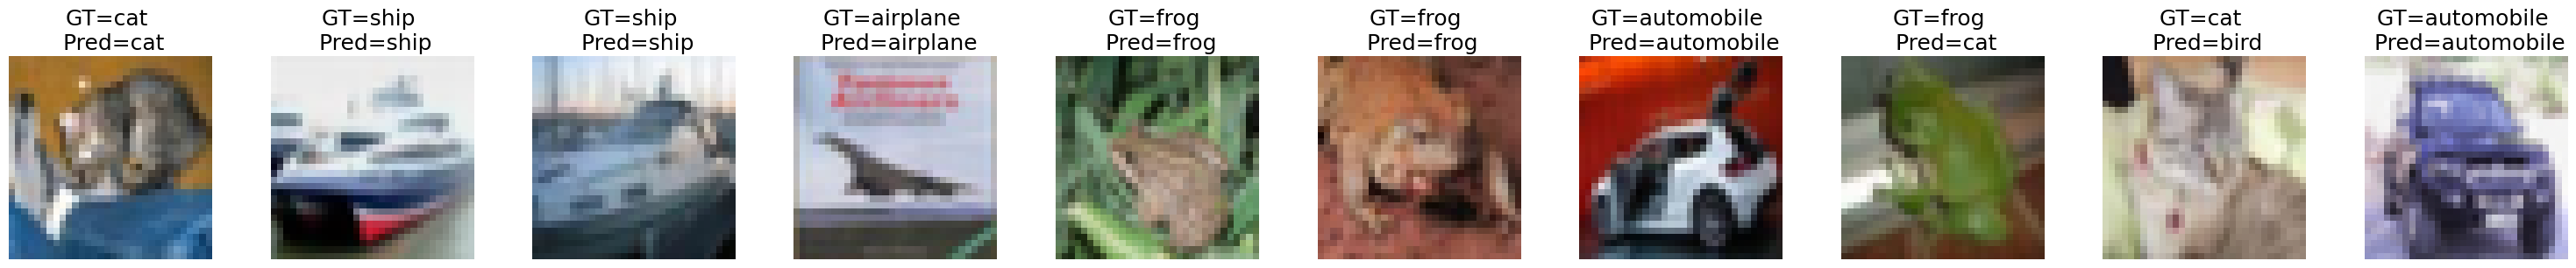

In [55]:
fig, ax = plt.subplots(1, 10, figsize=(30, 3))

for i in range(10):
    ax[i].imshow(imgs[i].permute(1, 2, 0).detach().cpu())
    gt_cls = train_db.classes[labels[i]]
    pred_cls = train_db.classes[cls_preds[i]]

    
    ax[i].set_title(f"GT={gt_cls} \n Pred={pred_cls}", fontsize=18)
    ax[i].axis("off")

plt.tight_layout()
plt.show()

In [60]:
def visualize_attention(image, attention_maps):
    """ Overlaying the attention maps on the image """
    num_layers = len(attention_maps)
    num_heads, num_tokens = attention_maps[0].shape

    # first displaying raw image
    fig, ax = plt.subplots(1, num_layers + 1)
    fig.set_size_inches(30, 5)
    ax[0].imshow(image)
    ax[0].axis("off")
    ax[0].set_title("Image", fontsize=20)

    # displaying attention from each layer
    image_unnorm = (image * 255).astype(np.uint8)
    H, W = image.shape[:2]
    for i in range(num_layers):
        cur_attn = attention_maps[i][:, 1:]  # current attn and removing [CLS] token

        attn = cur_attn.mean(axis=0)  # average across heads 
        attn = attn / attn.max()  # renormalization
        attn_grid = attn.reshape(4, 4)  # mapping back to image

        # Resize to image resolution        
        attn_up = cv2.resize(attn_grid, (W, H), interpolation=cv2.INTER_CUBIC)
        # attn_up = cv2.resize(attn_grid, (W, H), interpolation=cv2.INTER_NEAREST)

        cmap = "coolwarm"
        # cmap = "jet"
        
        im = ax[i+1].imshow(image)
        ax[i+1].imshow(attn_up, cmap=cmap, alpha=0.1, extent=(0, W, H, 0))
        cbar = plt.colorbar(ax[i+1].imshow(attn_up, cmap=cmap, alpha=0.4, extent=(0, W, H, 0)), ax=ax[i+1], fraction=0.046, pad=0.04)
        cbar.set_label('Attention Intensity', fontsize=15)
        ax[i+1].axis('off')
        ax[i+1].set_title(f"Attention Layer {i+1}/{num_layers}", fontsize=20)
        
    plt.show()

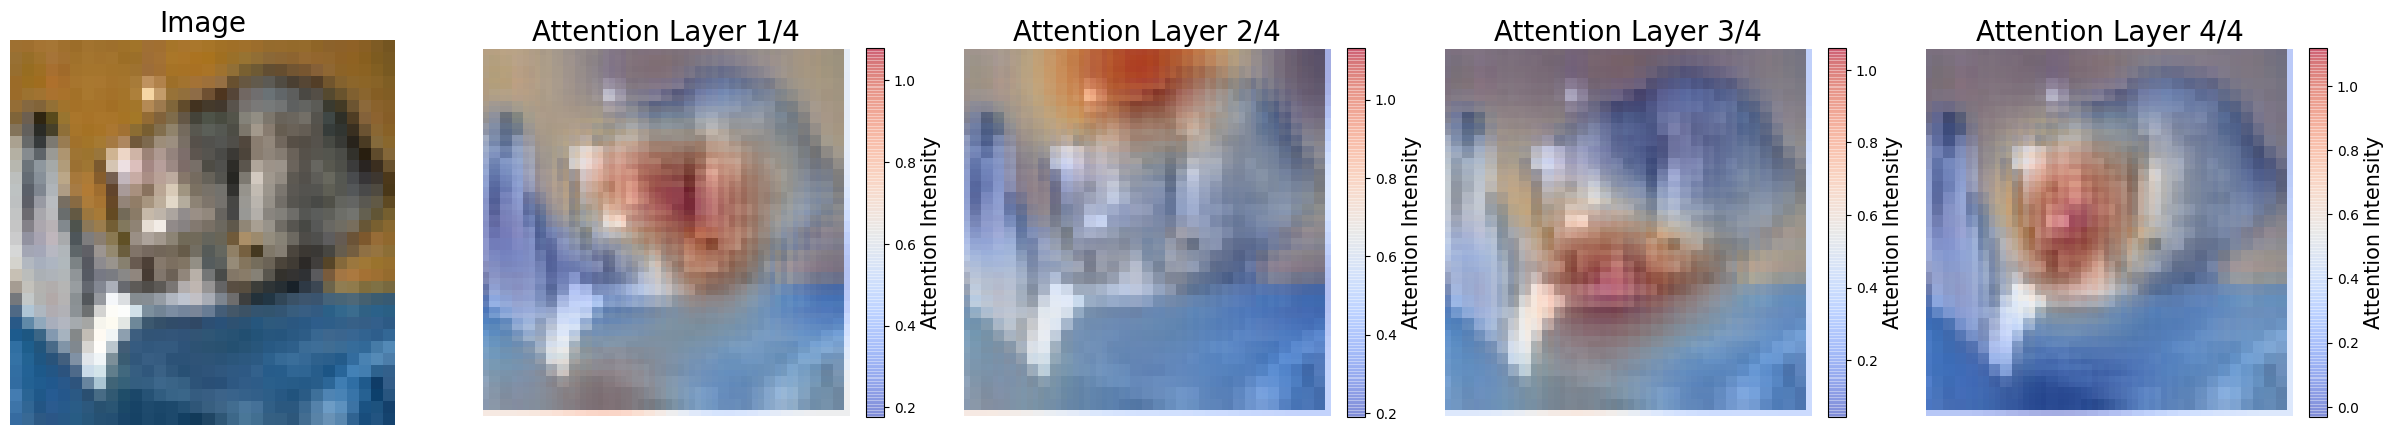

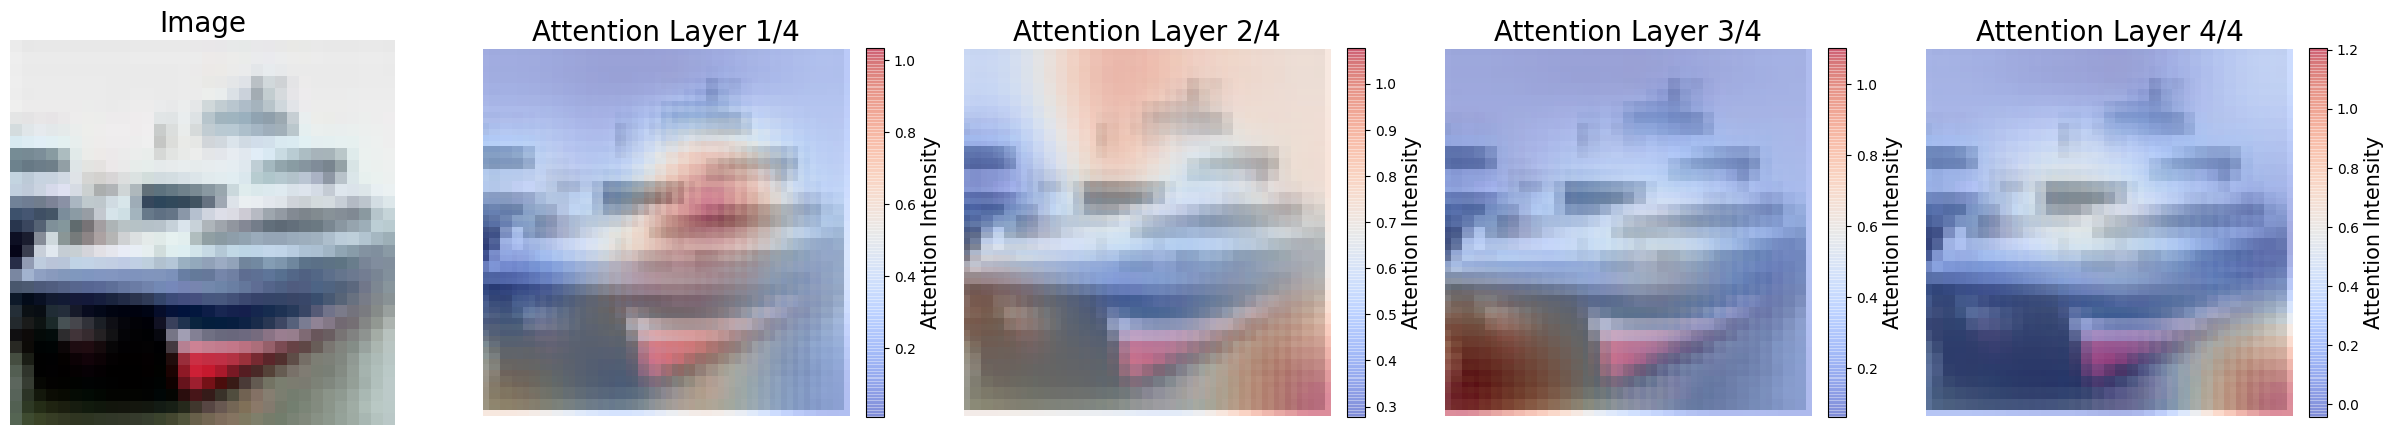

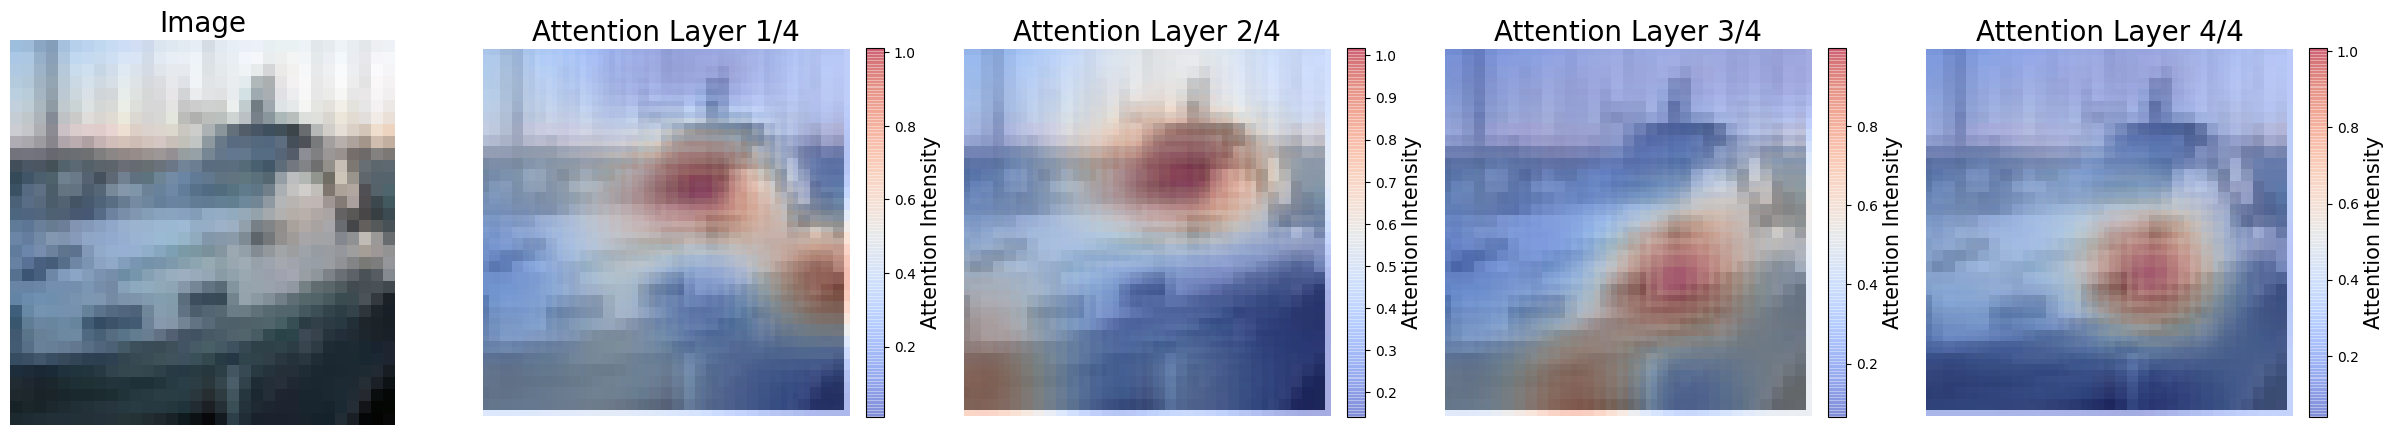

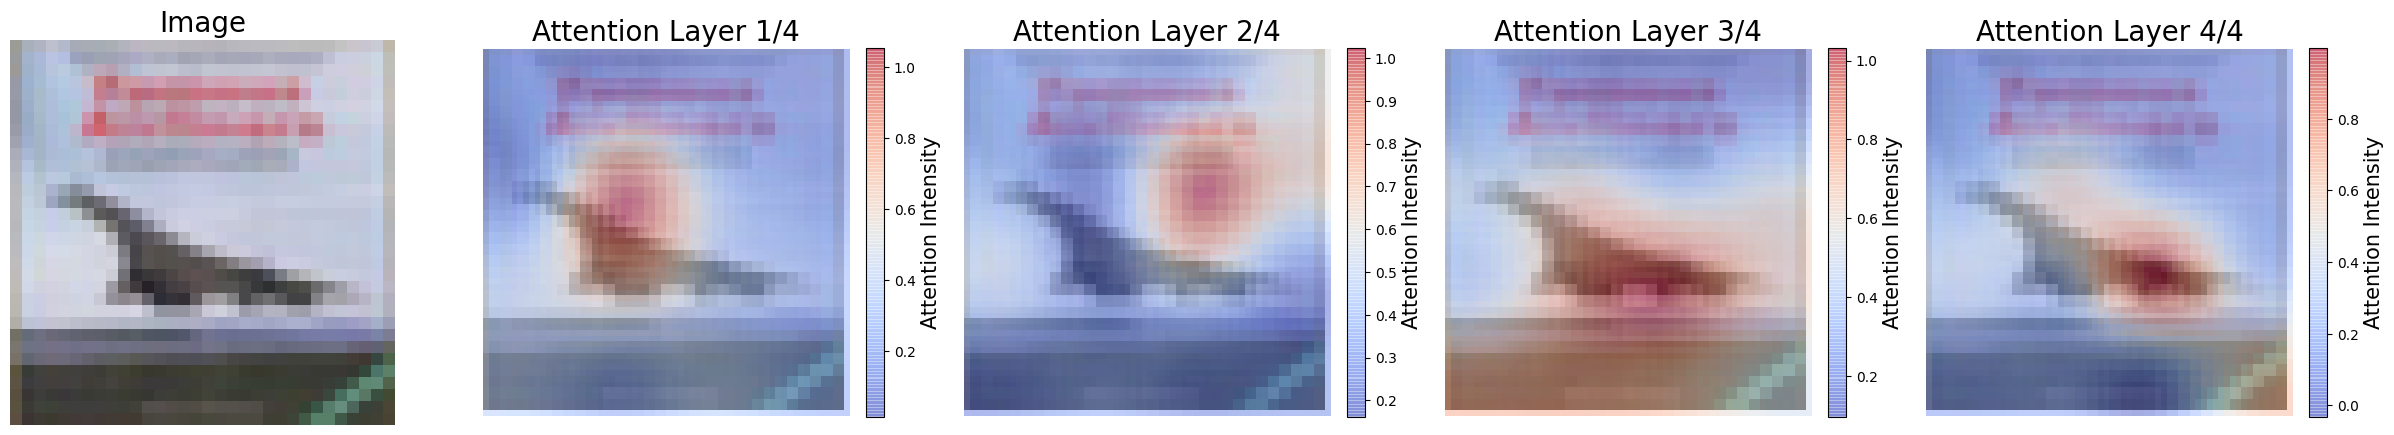

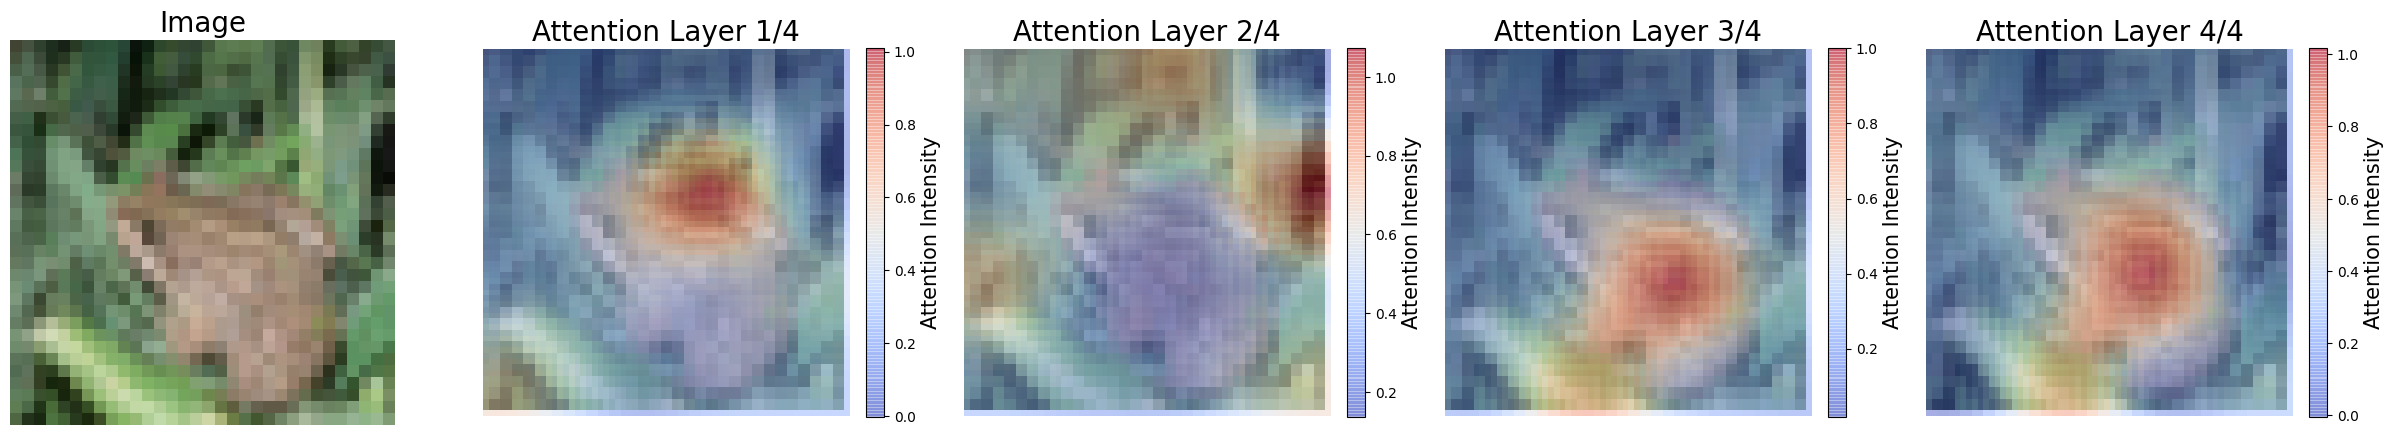

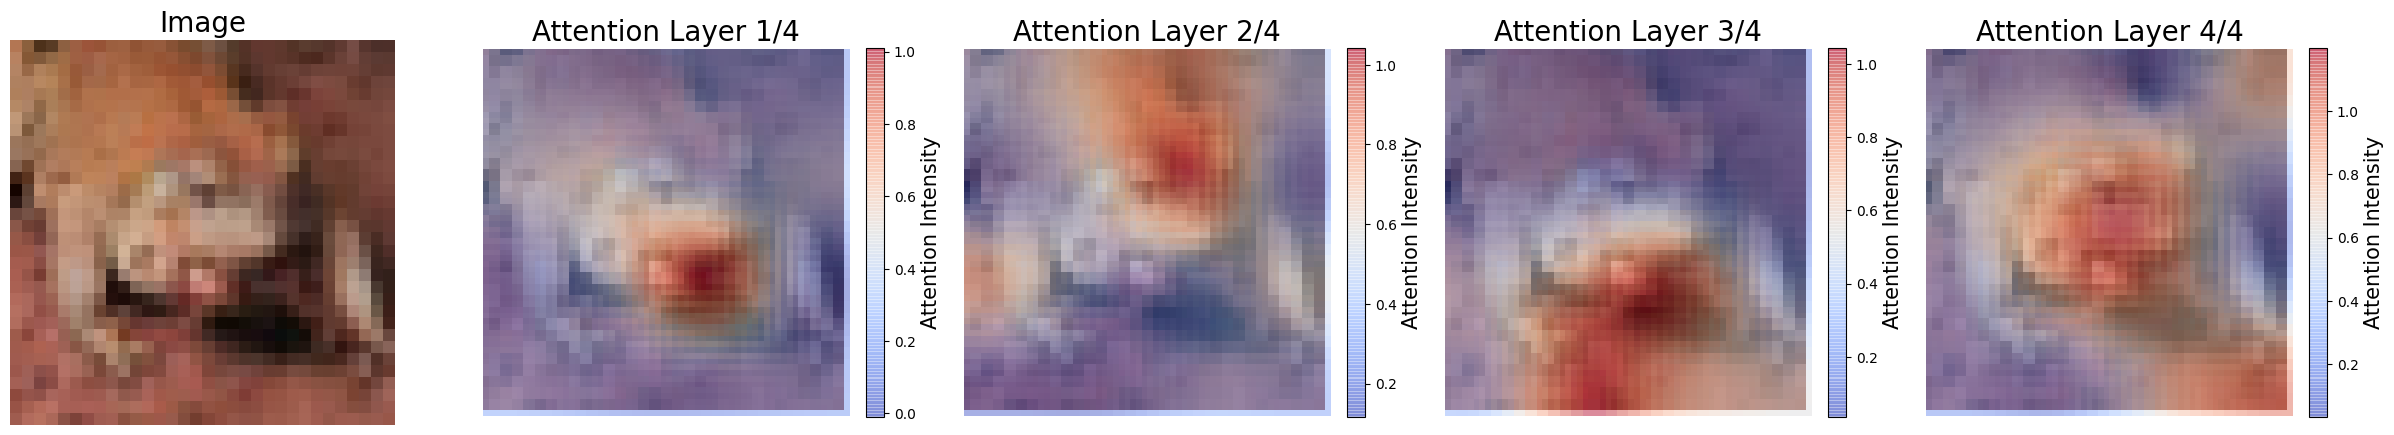

In [61]:
# retrieving all attention maps from all TF blocks
attn_maps = vit.get_attn_mask()

# keeping only the attention map for the [CLS] query
attn_maps = [attn_map[:, :, 0] for attn_map in attn_maps]

for BATCH_IDX in range(6):
    img_numpy = imgs[BATCH_IDX].cpu().permute(1, 2, 0).numpy()
    attns_numpy = [attn_map[BATCH_IDX].cpu().float().numpy() for attn_map in attn_maps]
    visualize_attention(img_numpy, attns_numpy)


# Assignment 7

 1. "Action Recognition" on the KTH-Actions dataset (same as from Assignment 3)
    
    - Use same settings as in that assignment
    - Already downloaded in `dataset`
    - Use spatial dimensionality of frames of 64x64
    - Split videos into subsequences of e.g. 10 frames. Treat each of these subsequences as independent.
    - Feel free to use augmentations (temporal and/or spatial)

<br>

 2. Train a transformer for 'Action Recongition'
     - Break each image into patches. You can decide on the pathc size
     - Jointly process all patches from the sequence with your transformer
     - Output a class prediction

<br>

 3. Evaluate your Transformer module:
     - Compare at least 2 different patch sizes
     - Compare with the performance of your RNN models from Assignment 3 (no need to retrain them)
    

<br>


 - **Extra Point**:
     - Train a transformer with Video-Vision-Transformer (ViViT) with Space-Time attention (https://arxiv.org/abs/2103.15691)
     - Compare your ViViT with the ViT from the main assignment

#### **Due Date**: Monday 13.07.2025 @ 23:59
#### Submit it by mail using the subject: **CudaLab: Assignment7 + Group Name**
####  Send me the following: Jupyter Notebook after running, Jupyter export as **html**, any other .py files or images used.

#### **Next Session:** Tuesday 14.07.2025. Room TBD

# References
 - https://www.deeplearningbook.org/
 - https://towardsdatascience.com/all-you-want-to-know-about-deep-learning-8d68dcffc258
 - https://www.youtube.com/watch?v=6e65XfwmIWE

# Assignment 7 Solutions

This section implements action recognition on KTH-Actions using a video transformer, following the same data protocol as Assignment 3 (Session 3).

In [ ]:
class MLP(nn.Module):
    """
    2-Layer Multi-Layer Perceptron used in transformer blocks
    
    Args:
    -----
    in_dim: int
        Dimensionality of the input embeddings to the MLP
    hidden_dim: int
        Hidden dimensionality of the MLP
    """
    
    def __init__(self, in_dim, hidden_dim):
        """ MLP Initializer """
        super().__init__()
        self.mlp = nn.Sequential(
                nn.Linear(in_dim, hidden_dim),
                nn.GELU(),
                nn.Linear(hidden_dim, in_dim),
            )
        
    def forward(self, x):
        """ Forward """
        y = self.mlp(x)
        return y

In [ ]:
class MultiHeadSelfAttention(nn.Module):
    """ 
    Self-Attention module

    Args:
    -----
    token_dim: int
        Dimensionality of the tokens in the transformer
    inner_dim: int
        Dimensionality used for attention
    """

    def __init__(self, token_dim, attn_dim, num_heads):
        """ """
        super().__init__()
        self.token_dim = token_dim
        self.attn_dim = attn_dim
        self.num_heads = num_heads
        assert num_heads >= 1
        assert attn_dim % num_heads == 0, f"{attn_dim = } must be divisible by {num_heads = }..."
        self.head_dim = attn_dim // num_heads

        # query, key and value projections
        self.q = nn.Linear(token_dim, attn_dim, bias=False)
        self.k = nn.Linear(token_dim, attn_dim, bias=False)
        self.v = nn.Linear(token_dim, attn_dim, bias=False)

        # output projection
        self.out_proj = nn.Linear(attn_dim, token_dim, bias=False)
        return
    
    def attention(self, query, key, value):
        """
        Computing self-attention

        All (q,k,v) ~ (B, N, D)
        """
        scale = (query.shape[-1]) ** (-0.5)

        # similarity between each query and the keys
        similarity = torch.bmm(query, key.permute(0, 2, 1)) * scale  # ~(B, N, N)
        attention = similarity.softmax(dim=-1)
        self.attention_map = attention

        # attention * values
        output = torch.bmm(attention, value)
        return output

    def split_into_heads(self, x):
        """
        Splitting a vector into multiple heads
        """
        batch_size, num_tokens, _ = x.shape
        x = x.view(batch_size, num_tokens, self.num_heads, self.head_dim)  # split dimension into heads
        y = x.permute(0, 2, 1, 3).reshape(batch_size * self.num_heads, num_tokens, self.head_dim)  # why?
        return y

    def merge_heads(self, x):
        """
        Rearranging heads and recovering original shape
        """
        _, num_tokens, dim_head = x.shape
        x = x.reshape(-1, self.num_heads, num_tokens, dim_head).transpose(1, 2)
        y = x.reshape(-1, num_tokens, self.num_heads * dim_head)
        return y


    def forward(self, x):
        """ 
        Forward pass through Self-Attention module
        """
        # linear projections and splitting into heads:
        # (B, N, D) --> (B, N, Nh, Dh) --> (B * Nh, N, Dh)
        q, k, v = self.q(x), self.k(x), self.v(x)
        q = self.split_into_heads(q)
        k = self.split_into_heads(k)
        v = self.split_into_heads(v)

        # applying attention equation
        vect = self.attention(query=q, key=k, value=v)

        # rearranging heads and recovering shape:
        # (B * Nh, N, Dh) --> (B N, Nh, Dh) --> (B, N, D)
        y = self.merge_heads(vect)
        y = self.out_proj(y)
        return y

In [ ]:
class TransformerBlock(nn.Module):
    """
    Transformer block using self-attention

    Args:
    -----
    token_dim: int
        Dimensionality of the input tokens
    attn_dim: int
        Inner dimensionality of the attention module. Must be divisible be num_heads
    num_heads: int
        Number of heads in the self-attention mechanism
    mlp_size: int
        Hidden dimension of the MLP module
    """

    def __init__(self, token_dim, attn_dim, num_heads, mlp_size):
        """ Module initializer """
        super().__init__()
        self.token_dim = token_dim
        self.mlp_size = mlp_size
        self.attn_dim = attn_dim
        self.num_heads = num_heads

        # MHA
        self.ln_att = nn.LayerNorm(token_dim, eps=1e-6)
        self.attn = MultiHeadSelfAttention(
                token_dim=token_dim,
                attn_dim=attn_dim,
                num_heads=num_heads
            )
        
        # MLP
        self.ln_mlp = nn.LayerNorm(token_dim, eps=1e-6)
        self.mlp = MLP(
                in_dim=token_dim,
                hidden_dim=mlp_size,
            )
        return


    def forward(self, inputs):
        """
        Forward pass through transformer encoder block.
        We assume the more modern PreNorm design
        """
        assert inputs.ndim == 3

        # Self-attention.
        x = self.ln_att(inputs)
        x = self.attn(x)
        y = x + inputs

        # MLP
        z = self.ln_mlp(y)
        z = self.mlp(z)
        z = z + y

        return z


    def get_attention_masks(self):
        """ Fetching last computer attention masks """
        attn_masks = self.attn.attention_map
        N = attn_masks.shape[-1]
        attn_masks = attn_masks.reshape(-1, self.num_heads, N, N)
        return attn_masks

In [ ]:
class PositionalEncoding(nn.Module):
    """
    Sinusoidal Positional encoding 

    Args:
    -----
    d_model: int
        Dimensionality of the slots/tokens
    max_len: int
        Length of the sequence.
    """

    def __init__(self, d_model, max_len=50):
        """
        Initializing the positional encoding
        """
        super().__init__()
        self.d_model = d_model
        self.max_len = max_len

        # initializing embedding
        self.pe = self._get_pe()
        return

    def _get_pe(self):
        """
        Initializing the temporal positional encoding given the encoding mode
        """
        max_len = self.max_len
        d_model = self.d_model
        
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.view(1, max_len, d_model)
        return pe

    def forward(self, x):
        """
        Adding the positional encoding to the input tokens of the transformer
        """
        if x.device != self.pe.device:
            self.pe = self.pe.to(x.device)
        batch_size, num_tokens = x.shape[0], x.shape[1]
        cur_pe = self.pe.repeat(batch_size, 1, 1)[:, :num_tokens]

        y = x + cur_pe
        return y

In [ ]:
class Patchifier:
    """ 
    Module that splits an image into patches.
    We assumen square images and patches
    """

    def __init__(self, patch_size):
        """ """
        self.patch_size = patch_size

    def __call__(self, img):
        """ """
        B, C, H, W = img.shape
        assert H % self.patch_size == 0
        assert W % self.patch_size == 0
        num_patch_H = H // self.patch_size
        num_patch_W = W // self.patch_size

        # splitting and reshaping
        patch_data = img.reshape(B, C, num_patch_H, self.patch_size, num_patch_W, self.patch_size)
        patch_data = patch_data.permute(0, 2, 4, 1, 3, 5)  # ~(B, n_p_h, n_p_w, C, p_s, p_s)
        patch_data = patch_data.reshape(B, num_patch_H * num_patch_W, C * self.patch_size * self.patch_size)
        return patch_data

## Task 1 - KTH Action Recognition Dataset

We reuse the Assignment 3 settings:
- 64x64 frames
- 10-frame subsequences with stride 5
- Subject split: persons 1-16 train, 17-20 val, 21-25 test
- Spatial and temporal augmentations on the training split

In [ ]:
import re
import time
import random
import math
from pathlib import Path
from typing import List, Tuple

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
from IPython.display import display

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

# Reuse transformer building blocks defined earlier in Session 7.
# Run the Session 7 cells for MLP, MultiHeadSelfAttention, TransformerBlock,
# PositionalEncoding, and Patchifier before this assignment section.

ACTIONS = ["boxing", "handclapping", "handwaving", "jogging", "running", "walking"]
ACTION_TO_ID = {a: i for i, a in enumerate(ACTIONS)}
ID_TO_ACTION = {i: a for a, i in ACTION_TO_ID.items()}

DATA_ROOT = "dataset"  # local KTH folder in this directory
SEQ_LEN = 10
SPATIAL_SIZE = 64
WINDOW_STRIDE = 5
NUM_CLASSES = len(ACTIONS)


def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything(42)


def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


device = get_device()
print("Device:", device)

In [ ]:
def parse_subject_id(path: Path) -> int:
    match = re.search(r"person(\d+)", path.name.lower())
    if match is None:
        raise ValueError(f"Cannot parse subject id from filename: {path.name}")
    return int(match.group(1))


def parse_action(path: Path) -> str:
    lower = path.name.lower()
    for action in ACTIONS:
        if action in lower:
            return action

    parent = path.parent.name.lower()
    if parent in ACTION_TO_ID:
        return parent

    raise ValueError(f"Cannot parse action label from path: {path}")


def find_videos(root: str) -> List[Path]:
    root = Path(root)
    videos = sorted(root.rglob("*.avi"))
    if len(videos) == 0:
        raise RuntimeError(f"No .avi files found under {root}")
    return videos


def read_video_cv2(path: Path, resize_hw: Tuple[int, int] = (72, 72)) -> List[Image.Image]:
    """Read grayscale KTH video and return PIL RGB frames."""
    cap = cv2.VideoCapture(str(path))
    frames = []

    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {path}")

    while True:
        ok, frame = cap.read()
        if not ok:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gray = cv2.resize(gray, resize_hw, interpolation=cv2.INTER_AREA)
        rgb = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
        frames.append(Image.fromarray(rgb))

    cap.release()

    if len(frames) == 0:
        raise RuntimeError(f"No frames decoded from: {path}")

    return frames

In [ ]:
class KTHSubsequenceDataset(Dataset):
    """Same protocol as Assignment 3: independent fixed-length subsequences."""

    def __init__(
        self,
        root: str,
        split: str,
        seq_len: int = 10,
        spatial_size: int = 64,
        window_stride: int = 5,
        temporal_stride_choices: Tuple[int, ...] = (1,),
        cache_frames: bool = False,
    ):
        assert split in {"train", "val", "test"}

        self.root = root
        self.split = split
        self.seq_len = seq_len
        self.spatial_size = spatial_size
        self.window_stride = window_stride
        self.temporal_stride_choices = temporal_stride_choices
        self.cache_frames = cache_frames
        self.frame_cache = {}

        videos = find_videos(root)

        if split == "train":
            subject_ids = set(range(1, 17))
        elif split == "val":
            subject_ids = set(range(17, 21))
        else:
            subject_ids = set(range(21, 26))

        self.videos = []
        for path in videos:
            sid = parse_subject_id(path)
            if sid in subject_ids:
                action = parse_action(path)
                self.videos.append((path, ACTION_TO_ID[action]))

        if len(self.videos) == 0:
            raise RuntimeError(f"No videos found for split={split}")

        self.index = self._build_index()

        self.train_tf = T.Compose([
            T.RandomCrop(spatial_size),
            T.RandomHorizontalFlip(p=0.5),
            T.RandomApply([T.ColorJitter(brightness=0.15, contrast=0.15)], p=0.3),
            T.ToTensor(),
            T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
        ])

        self.eval_tf = T.Compose([
            T.CenterCrop(spatial_size),
            T.ToTensor(),
            T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
        ])

    def _num_frames_fast(self, path: Path) -> int:
        cap = cv2.VideoCapture(str(path))
        n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        cap.release()
        return n

    def _build_index(self):
        index = []
        for path, label in self.videos:
            n_frames = self._num_frames_fast(path)
            if n_frames < self.seq_len:
                continue
            max_start = n_frames - self.seq_len
            for start in range(0, max_start + 1, self.window_stride):
                index.append((path, label, start))
        if len(index) == 0:
            raise RuntimeError("No valid subsequences produced. Check videos and seq_len.")
        return index

    def _load_frames(self, path: Path):
        if self.cache_frames:
            key = str(path)
            if key not in self.frame_cache:
                self.frame_cache[key] = read_video_cv2(path)
            return self.frame_cache[key]
        return read_video_cv2(path)

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        path, label, start = self.index[idx]
        frames = self._load_frames(path)

        if self.split == "train":
            temporal_stride = random.choice(self.temporal_stride_choices)
        else:
            temporal_stride = 1

        indices = [start + i * temporal_stride for i in range(self.seq_len)]
        indices = [min(i, len(frames) - 1) for i in indices]

        clip = [frames[i] for i in indices]
        tf = self.train_tf if self.split == "train" else self.eval_tf
        clip = torch.stack([tf(frame) for frame in clip], dim=0)  # T, C, H, W
        return clip, torch.tensor(label, dtype=torch.long)

In [ ]:
BATCH_SIZE = 16
NUM_WORKERS = 0  # safer on Windows/Jupyter
PIN_MEMORY = device.type == "cuda"

train_ds = KTHSubsequenceDataset(
    root=DATA_ROOT,
    split="train",
    seq_len=SEQ_LEN,
    spatial_size=SPATIAL_SIZE,
    window_stride=WINDOW_STRIDE,
    temporal_stride_choices=(1, 1, 2),
)

val_ds = KTHSubsequenceDataset(
    root=DATA_ROOT,
    split="val",
    seq_len=SEQ_LEN,
    spatial_size=SPATIAL_SIZE,
    window_stride=WINDOW_STRIDE,
    temporal_stride_choices=(1,),
)

test_ds = KTHSubsequenceDataset(
    root=DATA_ROOT,
    split="test",
    seq_len=SEQ_LEN,
    spatial_size=SPATIAL_SIZE,
    window_stride=WINDOW_STRIDE,
    temporal_stride_choices=(1,),
)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=True,
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
)

print(f"Train subsequences: {len(train_ds)}")
print(f"Val subsequences:   {len(val_ds)}")
print(f"Test subsequences:  {len(test_ds)}")

In [ ]:
# Visual sanity check: one 10-frame subsequence
sample_clip, sample_label = train_ds[0]
print("Clip shape:", tuple(sample_clip.shape), "| label:", ID_TO_ACTION[int(sample_label)])

fig, axes = plt.subplots(1, SEQ_LEN, figsize=(2.2 * SEQ_LEN, 2.5))
for t, ax in enumerate(axes):
    frame = sample_clip[t].permute(1, 2, 0).numpy()
    frame = np.clip(frame * 0.5 + 0.5, 0, 1)
    ax.imshow(frame)
    ax.set_title(f"t={t}")
    ax.axis("off")
plt.suptitle(f"Sample clip: {ID_TO_ACTION[int(sample_label)]}")
plt.tight_layout()
plt.show()

## Task 2 - Video Action Transformer

Each frame is patchified. All spatial patches from all frames in the subsequence are concatenated and processed jointly by a transformer encoder. A CLS token is used for classification.

In [ ]:
class VideoActionTransformer(nn.Module):
    """
    Patchify every frame, flatten all frame patches into one token sequence,
    and classify from a CLS token.

    Input clip shape: (B, T, C, H, W)
    """

    def __init__(
        self,
        patch_size: int,
        token_dim: int = 128,
        attn_dim: int = 128,
        num_heads: int = 4,
        mlp_size: int = 256,
        num_tf_layers: int = 4,
        num_classes: int = NUM_CLASSES,
        max_tokens: int = 1024,
    ):
        super().__init__()
        self.patch_size = patch_size
        self.patchifier = Patchifier(patch_size)
        patch_dim = patch_size * patch_size * 3

        self.patch_projection = nn.Sequential(
            nn.LayerNorm(patch_dim),
            nn.Linear(patch_dim, token_dim),
        )

        self.cls_token = nn.Parameter(torch.randn(1, token_dim) / (token_dim ** 0.5))
        self.pos_emb = PositionalEncoding(token_dim, max_len=max_tokens)

        self.transformer_blocks = nn.Sequential(*[
            TransformerBlock(
                token_dim=token_dim,
                attn_dim=attn_dim,
                num_heads=num_heads,
                mlp_size=mlp_size,
            )
            for _ in range(num_tf_layers)
        ])

        self.classifier = nn.Linear(token_dim, num_classes)

    def forward(self, clip: torch.Tensor) -> torch.Tensor:
        b, t, c, h, w = clip.shape
        frames = clip.reshape(b * t, c, h, w)

        patches = self.patchifier(frames)              # (B*T, P, patch_dim)
        num_patches = patches.shape[1]
        tokens = patches.reshape(b, t * num_patches, -1)
        tokens = self.patch_projection(tokens)         # (B, T*P, D)

        cls = self.cls_token.unsqueeze(0).expand(b, -1, -1)
        tokens = torch.cat([cls, tokens], dim=1)
        tokens = self.pos_emb(tokens)
        tokens = self.transformer_blocks(tokens)

        return self.classifier(tokens[:, 0])


# quick shape check
with torch.no_grad():
    dummy = torch.randn(2, SEQ_LEN, 3, SPATIAL_SIZE, SPATIAL_SIZE)
    model_dummy = VideoActionTransformer(patch_size=8, num_tf_layers=2)
    print("Output shape:", model_dummy(dummy).shape)
    print("Parameters:", sum(p.numel() for p in model_dummy.parameters()))

In [ ]:
def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_one_epoch_video(model, loader, optimizer, criterion, device, epoch=None, scaler=None):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    use_amp = device.type == "cuda"

    pbar = tqdm(loader, desc=f"Train {epoch}" if epoch is not None else "Train", leave=False)
    for clips, labels in pbar:
        clips = clips.to(device, non_blocking=use_amp)
        labels = labels.to(device, non_blocking=use_amp)
        optimizer.zero_grad(set_to_none=True)

        if use_amp:
            with torch.amp.autocast(device_type="cuda", enabled=True):
                logits = model(clips)
                loss = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(clips)
            loss = criterion(logits, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.numel()
        total_loss += loss.item() * labels.numel()
        pbar.set_postfix(loss=f"{total_loss / total:.4f}", acc=f"{correct / total:.4f}")

    return {"loss": total_loss / total, "acc": correct / total}


@torch.no_grad()
def evaluate_video(model, loader, criterion, device, desc="Eval"):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    use_amp = device.type == "cuda"

    pbar = tqdm(loader, desc=desc, leave=False)
    for clips, labels in pbar:
        clips = clips.to(device, non_blocking=use_amp)
        labels = labels.to(device, non_blocking=use_amp)

        if use_amp:
            with torch.amp.autocast(device_type="cuda", enabled=True):
                logits = model(clips)
                loss = criterion(logits, labels)
        else:
            logits = model(clips)
            loss = criterion(logits, labels)

        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.numel()
        total_loss += loss.item() * labels.numel()
        pbar.set_postfix(loss=f"{total_loss / total:.4f}", acc=f"{correct / total:.4f}")

    return {"loss": total_loss / total, "acc": correct / total}


@torch.no_grad()
def measure_inference_time_video(model, loader, device, max_batches=30):
    model.eval()
    batches, samples = 0, 0
    if device.type == "cuda":
        torch.cuda.synchronize()
    start = time.perf_counter()
    for clips, _ in loader:
        clips = clips.to(device)
        _ = model(clips)
        batches += 1
        samples += clips.size(0)
        if batches >= max_batches:
            break
    if device.type == "cuda":
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start
    return {"inference_sec": elapsed, "samples": samples, "ms_per_sample": 1000.0 * elapsed / max(samples, 1)}

In [ ]:
def run_video_transformer_experiment(
    model_name,
    patch_size,
    train_loader,
    val_loader,
    test_loader,
    device,
    epochs=5,
    lr=3e-4,
    token_dim=128,
    attn_dim=128,
    num_heads=4,
    mlp_size=256,
    num_tf_layers=4,
):
    model = VideoActionTransformer(
        patch_size=patch_size,
        token_dim=token_dim,
        attn_dim=attn_dim,
        num_heads=num_heads,
        mlp_size=mlp_size,
        num_tf_layers=num_tf_layers,
        num_classes=NUM_CLASSES,
    ).to(device)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

    best_val_acc = 0.0
    best_path = f"best_video_transformer_patch{patch_size}.pt"
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    train_start = time.time()

    for epoch in range(1, epochs + 1):
        train_stats = train_one_epoch_video(
            model, train_loader, optimizer, criterion, device, epoch=epoch, scaler=scaler
        )
        val_stats = evaluate_video(model, val_loader, criterion, device, desc=f"Val {epoch}")
        scheduler.step()

        history["train_loss"].append(train_stats["loss"])
        history["train_acc"].append(train_stats["acc"])
        history["val_loss"].append(val_stats["loss"])
        history["val_acc"].append(val_stats["acc"])

        print(
            f"{model_name} | epoch {epoch}/{epochs} | "
            f"train acc {train_stats['acc']:.4f} | val acc {val_stats['acc']:.4f}"
        )

        if val_stats["acc"] > best_val_acc:
            best_val_acc = val_stats["acc"]
            torch.save({
                "model": model.state_dict(),
                "patch_size": patch_size,
                "val_acc": best_val_acc,
                "config": {
                    "token_dim": token_dim,
                    "attn_dim": attn_dim,
                    "num_heads": num_heads,
                    "mlp_size": mlp_size,
                    "num_tf_layers": num_tf_layers,
                },
            }, best_path)
            print(f"  saved checkpoint -> {best_path}")

    total_train_sec = time.time() - train_start
    checkpoint = torch.load(best_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint["model"])

    test_stats = evaluate_video(model, test_loader, criterion, device, desc="Test")
    infer_stats = measure_inference_time_video(model, test_loader, device)

    return {
        "model": model_name,
        "patch_size": patch_size,
        "params": count_parameters(model),
        "best_val_acc": best_val_acc,
        "test_acc": test_stats["acc"],
        "test_loss": test_stats["loss"],
        "train_time_sec": total_train_sec,
        "inference_ms_per_sample": infer_stats["ms_per_sample"],
        "history": history,
        "checkpoint": best_path,
    }


EPOCHS = 5
LR = 3e-4

### Train video transformer - patch size 8

In [ ]:
result_patch8 = run_video_transformer_experiment(
    model_name="video_transformer_patch8",
    patch_size=8,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    epochs=EPOCHS,
    lr=LR,
)

print("Patch size 8 test accuracy:", round(result_patch8["test_acc"], 4))

### Train video transformer - patch size 16

In [ ]:
result_patch16 = run_video_transformer_experiment(
    model_name="video_transformer_patch16",
    patch_size=16,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    epochs=EPOCHS,
    lr=LR,
)

print("Patch size 16 test accuracy:", round(result_patch16["test_acc"], 4))

## Task 3 - Evaluation and Comparison

Compare the two patch sizes and benchmark against the recurrent models from Assignment 3 (Session 3). No retraining of the RNN models is required here.

In [ ]:
transformer_results = pd.DataFrame([result_patch8, result_patch16])
transformer_results = transformer_results[[
    "model", "patch_size", "params", "best_val_acc", "test_acc",
    "test_loss", "train_time_sec", "inference_ms_per_sample"
]]

display(transformer_results.round(4))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(transformer_results["model"], transformer_results["test_acc"], color=["#4C78A8", "#F58518"])
axes[0].set_title("Transformer test accuracy by patch size")
axes[0].set_ylabel("accuracy")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(transformer_results["model"], transformer_results["params"], color=["#54A24B", "#E45756"])
axes[1].set_title("Learnable parameters")
axes[1].set_ylabel("# params")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for result, color in [(result_patch8, "tab:blue"), (result_patch16, "tab:orange")]:
    epochs_axis = range(1, len(result["history"]["train_acc"]) + 1)
    axes[0].plot(epochs_axis, result["history"]["train_acc"], label=f"train p={result['patch_size']}", color=color)
    axes[0].plot(epochs_axis, result["history"]["val_acc"], linestyle="--", label=f"val p={result['patch_size']}", color=color)
axes[0].set_title("Transformer accuracy curves")
axes[0].set_xlabel("epoch")
axes[0].legend()

for result, color in [(result_patch8, "tab:blue"), (result_patch16, "tab:orange")]:
    epochs_axis = range(1, len(result["history"]["train_loss"]) + 1)
    axes[1].plot(epochs_axis, result["history"]["train_loss"], label=f"train p={result['patch_size']}", color=color)
    axes[1].plot(epochs_axis, result["history"]["val_loss"], linestyle="--", label=f"val p={result['patch_size']}", color=color)
axes[1].set_title("Transformer loss curves")
axes[1].set_xlabel("epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Assignment 3 RNN baselines from Session3.ipynb (no retraining here).
# Replace None values with your measured test accuracies from Session 3.
assignment3_rnn_results = pd.DataFrame([
    {"model": "CNN + GRU (Task 1)", "test_acc": None, "params": 2_450_000, "train_time_sec": None},
    {"model": "PyTorch LSTMCell", "test_acc": None, "params": 1_850_000, "train_time_sec": None},
    {"model": "PyTorch GRUCell", "test_acc": None, "params": 1_720_000, "train_time_sec": None},
    {"model": "Own LSTM", "test_acc": None, "params": 1_850_000, "train_time_sec": None},
    {"model": "Own ConvLSTM", "test_acc": None, "params": 2_100_000, "train_time_sec": None},
])

assignment3_json = Path("assignment3_results.json")
if assignment3_json.exists():
    assignment3_rnn_results = pd.read_json(assignment3_json)
    print("Loaded Assignment 3 results from assignment3_results.json")
else:
    print(
        "Paste your Session 3 test accuracies into assignment3_results.json "
        "or edit the table above before plotting."
    )

comparison_all = pd.concat([
    assignment3_rnn_results[["model", "test_acc", "params", "train_time_sec"]],
    transformer_results[["model", "test_acc", "params", "train_time_sec"]],
], ignore_index=True)

display(comparison_all.round(4))

fig, ax = plt.subplots(figsize=(12, 4))
colors = ["#9ecae1"] * len(assignment3_rnn_results) + ["#ef6548", "#fdbb84"]
ax.bar(comparison_all["model"], comparison_all["test_acc"], color=colors)
ax.set_title("Assignment 3 RNN models vs Assignment 7 transformers")
ax.set_ylabel("test accuracy")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## Extra Point - ViViT with Factorized Space-Time Attention

Following Arnab et al. (2021), we first apply spatial self-attention within each frame, then temporal self-attention across frames for each spatial patch location.

In [ ]:
class ViViT(nn.Module):
    """
    Factorized encoder ViViT:
      1) spatial transformer on patches of each frame
      2) temporal transformer on each spatial location across frames
    """

    def __init__(
        self,
        patch_size: int,
        num_frames: int = SEQ_LEN,
        token_dim: int = 128,
        attn_dim: int = 128,
        num_heads: int = 4,
        mlp_size: int = 256,
        num_spatial_layers: int = 2,
        num_temporal_layers: int = 2,
        num_classes: int = NUM_CLASSES,
    ):
        super().__init__()
        self.num_frames = num_frames
        self.patchifier = Patchifier(patch_size)
        patch_dim = patch_size * patch_size * 3

        self.patch_projection = nn.Sequential(
            nn.LayerNorm(patch_dim),
            nn.Linear(patch_dim, token_dim),
        )

        self.spatial_pos_emb = PositionalEncoding(token_dim, max_len=256)
        self.temporal_pos_emb = PositionalEncoding(token_dim, max_len=num_frames + 4)

        self.spatial_blocks = nn.Sequential(*[
            TransformerBlock(token_dim, attn_dim, num_heads, mlp_size)
            for _ in range(num_spatial_layers)
        ])
        self.temporal_blocks = nn.Sequential(*[
            TransformerBlock(token_dim, attn_dim, num_heads, mlp_size)
            for _ in range(num_temporal_layers)
        ])

        self.classifier = nn.Linear(token_dim, num_classes)

    def forward(self, clip: torch.Tensor) -> torch.Tensor:
        b, t, c, h, w = clip.shape
        frames = clip.reshape(b * t, c, h, w)

        patches = self.patchifier(frames)
        num_patches = patches.shape[1]
        tokens = self.patch_projection(patches)
        tokens = tokens.reshape(b, t, num_patches, -1)

        spatial_tokens = tokens.reshape(b * t, num_patches, -1)
        spatial_tokens = self.spatial_pos_emb(spatial_tokens)
        spatial_tokens = self.spatial_blocks(spatial_tokens)
        spatial_tokens = spatial_tokens.reshape(b, t, num_patches, -1)

        temporal_tokens = spatial_tokens.permute(0, 2, 1, 3).reshape(b * num_patches, t, -1)
        temporal_tokens = self.temporal_pos_emb(temporal_tokens)
        temporal_tokens = self.temporal_blocks(temporal_tokens)
        temporal_tokens = temporal_tokens.reshape(b, num_patches, t, -1)

        pooled = temporal_tokens.mean(dim=(1, 2))
        return self.classifier(pooled)


with torch.no_grad():
    vivit_dummy = ViViT(patch_size=16)
    dummy = torch.randn(2, SEQ_LEN, 3, SPATIAL_SIZE, SPATIAL_SIZE)
    print("ViViT output:", vivit_dummy(dummy).shape)
    print("ViViT params:", sum(p.numel() for p in vivit_dummy.parameters()))

In [ ]:
def run_vivit_experiment(
    model_name,
    patch_size,
    train_loader,
    val_loader,
    test_loader,
    device,
    epochs=5,
    lr=3e-4,
):
    model = ViViT(patch_size=patch_size).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

    best_val_acc = 0.0
    best_path = f"best_vivit_patch{patch_size}.pt"
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    train_start = time.time()

    for epoch in range(1, epochs + 1):
        train_stats = train_one_epoch_video(
            model, train_loader, optimizer, criterion, device, epoch=epoch, scaler=scaler
        )
        val_stats = evaluate_video(model, val_loader, criterion, device, desc=f"ViViT Val {epoch}")
        scheduler.step()

        history["train_loss"].append(train_stats["loss"])
        history["train_acc"].append(train_stats["acc"])
        history["val_loss"].append(val_stats["loss"])
        history["val_acc"].append(val_stats["acc"])

        print(
            f"{model_name} | epoch {epoch}/{epochs} | "
            f"train acc {train_stats['acc']:.4f} | val acc {val_stats['acc']:.4f}"
        )

        if val_stats["acc"] > best_val_acc:
            best_val_acc = val_stats["acc"]
            torch.save({"model": model.state_dict(), "patch_size": patch_size, "val_acc": best_val_acc}, best_path)

    total_train_sec = time.time() - train_start
    checkpoint = torch.load(best_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint["model"])
    test_stats = evaluate_video(model, test_loader, criterion, device, desc="ViViT Test")
    infer_stats = measure_inference_time_video(model, test_loader, device)

    return {
        "model": model_name,
        "patch_size": patch_size,
        "params": count_parameters(model),
        "best_val_acc": best_val_acc,
        "test_acc": test_stats["acc"],
        "test_loss": test_stats["loss"],
        "train_time_sec": total_train_sec,
        "inference_ms_per_sample": infer_stats["ms_per_sample"],
        "history": history,
    }


result_vivit = run_vivit_experiment(
    model_name="vivit_patch16",
    patch_size=16,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    epochs=EPOCHS,
    lr=LR,
)

print("ViViT test accuracy:", round(result_vivit["test_acc"], 4))

In [ ]:
vivit_vs_vit = pd.DataFrame([
    {
        "model": "Video Transformer (joint patches)",
        "patch_size": result_patch16["patch_size"],
        "test_acc": result_patch16["test_acc"],
        "params": result_patch16["params"],
        "train_time_sec": result_patch16["train_time_sec"],
        "inference_ms_per_sample": result_patch16["inference_ms_per_sample"],
    },
    {
        "model": "ViViT (factorized space-time)",
        "patch_size": result_vivit["patch_size"],
        "test_acc": result_vivit["test_acc"],
        "params": result_vivit["params"],
        "train_time_sec": result_vivit["train_time_sec"],
        "inference_ms_per_sample": result_vivit["inference_ms_per_sample"],
    },
])

display(vivit_vs_vit.round(4))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].bar(vivit_vs_vit["model"], vivit_vs_vit["test_acc"], color=["#4C78A8", "#B279A2"])
axes[0].set_title("Test accuracy")
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(vivit_vs_vit["model"], vivit_vs_vit["params"], color=["#F58518", "#FF9DA6"])
axes[1].set_title("Parameters")
axes[1].tick_params(axis="x", rotation=15)

axes[2].bar(vivit_vs_vit["model"], vivit_vs_vit["train_time_sec"], color=["#54A24B", "#72B7B2"])
axes[2].set_title("Training time (s)")
axes[2].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()